In [1]:
%run setup.py

import pandas as pd
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

2025-11-25 14:51:12.685105: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 14:51:14.691672: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 14:51:16.245022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764093077.462184    5964 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764093077.810846    5964 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764093080.749248    5964 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [4]:
def preprocessing(df, sensor_columns):
    x_list = []

    for col in sensor_columns:
        sensor_data = np.stack(df[col].values)
        x_list.append(sensor_data)
    
    X = np.stack(x_list, axis=2)

    le = LabelEncoder()
    y = le.fit_transform(df['label'])

    return X, y, le

In [ ]:
def lstm_model(input_shape, num_classes):
    model = models.Sequential()

    model.add(layers.Input(shape=input_shape))

    model.add(layers.BatchNormalization())
    
    model.add(layers.Bidirectional(layers.LSTM(units=16, return_sequences=True)))
    model.add(layers.Dropout(0.2))

    model.add(layers.Bidirectional(layers.LSTM(units=16, return_sequences=False)))
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [6]:
def show_metrics(accuracies, f1_scores, matrices, classes):
    print("Accuracy:", np.mean(accuracies))
    print("F1 Score (weighted):", np.mean([f[0] for f in f1_scores]))
    print("F1 Score (macro):", np.mean([f[1] for f in f1_scores]))

    global_matrix = np.sum(matrices, axis=0)

    disp = ConfusionMatrixDisplay(confusion_matrix=global_matrix, display_labels=classes)
    disp.plot(xticks_rotation=45)
    plt.show()

In [7]:
def calculate_class_weights(df):
    unique_classes, count = np.unique(df["label"], return_counts=True)
    total_sample = len(df)
    n_classes = len(unique_classes)

    weights = {}
    for cls, cnt in zip(unique_classes, count):
        weight = total_sample / (n_classes * cnt)
        weights[cls] = weight

    return weights

In [2]:
df = pl.read_parquet("../data/DogDeepLearning.parquet")
df = df.to_pandas()

Training and evaluating for DogID: 73 (1/10)
Training and evaluating for DogID: 34 (2/10)
Training and evaluating for DogID: 45 (3/10)
Training and evaluating for DogID: 44 (4/10)
Training and evaluating for DogID: 55 (5/10)
Training and evaluating for DogID: 27 (6/10)
Training and evaluating for DogID: 16 (7/10)
Training and evaluating for DogID: 63 (8/10)
Training and evaluating for DogID: 29 (9/10)
Training and evaluating for DogID: 48 (10/10)
Accuracy: 0.7443137109279633
F1 Score (weighted): 0.7337357647472681
F1 Score (macro): 0.7268181278281078


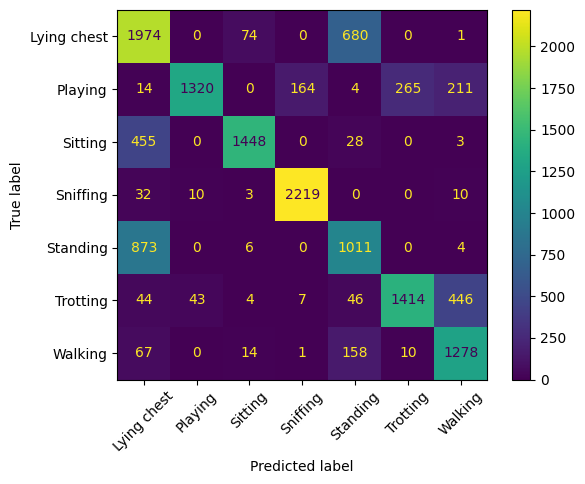

In [12]:
sensor_cols = [
    'ABack_x', 'ABack_y', 'ABack_z',
    'ANeck_x', 'ANeck_y', 'ANeck_z',
    'GBack_x', 'GBack_y', 'GBack_z',
    'GNeck_x', 'GNeck_y', 'GNeck_z'
]

dogs_tests = [73, 34, 45, 44, 55, 27, 16, 63, 29, 48]

accuracies = []
f1_scores = []
matrices = []

for i, dog_id in enumerate(dogs_tests):
    print(f"Training and evaluating for DogID: {dog_id} ({i+1}/{len(dogs_tests)})")
    df_train = df[df["DogID"] != dog_id].copy()
    df_test = df[df["DogID"] == dog_id].copy()

    X_train, y_train, le = preprocessing(df_train, sensor_cols)
    X_test, y_test, _ = preprocessing(df_test, sensor_cols)

    num_classes = len(np.unique(y_train))

    model = lstm_model(input_shape=(200, 12), num_classes=num_classes)

    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[callback],
        verbose=0
    )

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    cm = confusion_matrix(y_test, y_pred)
    matrices.append(cm)

    accuracies.append(model.evaluate(X_test, y_test, verbose=0)[1])
    f1_scores.append((f1_weighted, f1_macro))

show_metrics(accuracies, f1_scores, matrices, le.classes_)